# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [ ]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.5 MB/s eta 0:00:00


In [ ]:
# Set up GEE API
import ee
ee.Authenticate()
# ee.Initialize(project='earthengine-ml-testing') #<- Remember to change this to your own project's name!
ee.Initialize(project='earthenginetest-504004')


In [ ]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [ ]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [ ]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

**Answer:** While a median composite (.median()) takes the pixel-wise median across the time-series stack to remove transient cloud artifacts and shadows, alternative mathematical compositing approaches in Earth Engine include:

1). Mean Composite (.mean()): It computes the arithmetic mean of all unmasked observations per pixel. Smooths radiometric noise, but remains sensitive to residual cloud/shadow outliers.

2). Maximum/Minimum Value Composite (.max(), .min(), or .qualityMosaic('NDVI')): It selects the observation that maximizes or minimizes a specific metric (e.g., peak vegetation greenness via NDVI). Preserves real multi-band spectral relationships for each pixel observation.

3). Percentile Composite (.reduce(ee.Reducer.percentile([20]))): This selects a specific percentile threshold (e.g., 20th percentile) across the stack to systematically reject high-reflectance cloud edge artifacts.

4). Medoid Composite (ee.Reducer.medoid()): It selects the single real pixel observation whose multi-dimensional spectral distance is closest to the multi-band median, preserving true inter-band physical consistency.

In [ ]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [ ]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

**Answer:** The European Space Agency (ESA) WorldCover dataset (ee.Image('ESA/WorldCover/v100/2020')) was created using satellite observations from 2020.

In [ ]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [ ]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

**Answer:** With the random seed set to 2, sample number 2 in the training dataset is classified as class 8. According to the remapping scheme - which scales original ESA WorldCover classes 10 through 100 down to 1 through 10 - this corresponds to class 80, whihc represents Permanent Water Bodies. This classification is physically supported by low reflectance across all four spectral bands, with an exceptionally low response in the Near-Infrared band(B8).

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [ ]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [ ]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [ ]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [ ]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

Answer: The ESA WorldCover reference map and the Random Forest (RF) classified Sentinel-2 map exhibit clear spatial and accuracy differences:

1). Spatial Granularity & Speckle (Salt-and-Pepper Noise): The RF-classified map displays pixel-level speckle noise, whereas the ESA map features smooth, contiguous landcover boundaries. The RF model predicts each pixel independently using 4 spectral bands (B2, B3, B4, B8) from a single composite, while ESA uses multi-temporal radar (Sentinel-1) + optical time series with spatial post-filtering.

2). Terrain & Shadow Misclassification: Steep, shaded hillslopes in Wellington are misclassified in the RF map as Water or Built-up. Shaded vegetation has low optical reflectance; without topographic normalization (DEM slope/aspect) or SWIR bands (B11, B12), shadow pixels spectrally mimic water bodies.

3). Class Discrepancy in Transition Zones: Transitional boundaries between shrubland, grassland, and urban edges show high disagreement. Random sampling of 5,000 pixels across the AOI produces class imbalance, causing dominant classes (Tree cover) to over-influence decision tree splits at the expense of minority classes.

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Overall test accuracy (this is the number we put in the Q5 figure)
test_accuracy_2020 = accuracy_score(y_true, y_pred)

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)
print(f"\nOverall Test Accuracy (2020): {test_accuracy_2020:.3f}")

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       230        1       31        0        2        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        39        0      154        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        3        0       23        2        0   
Actual 60         0        0        1        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        6        0        0   
Actual 90         0        0        3        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


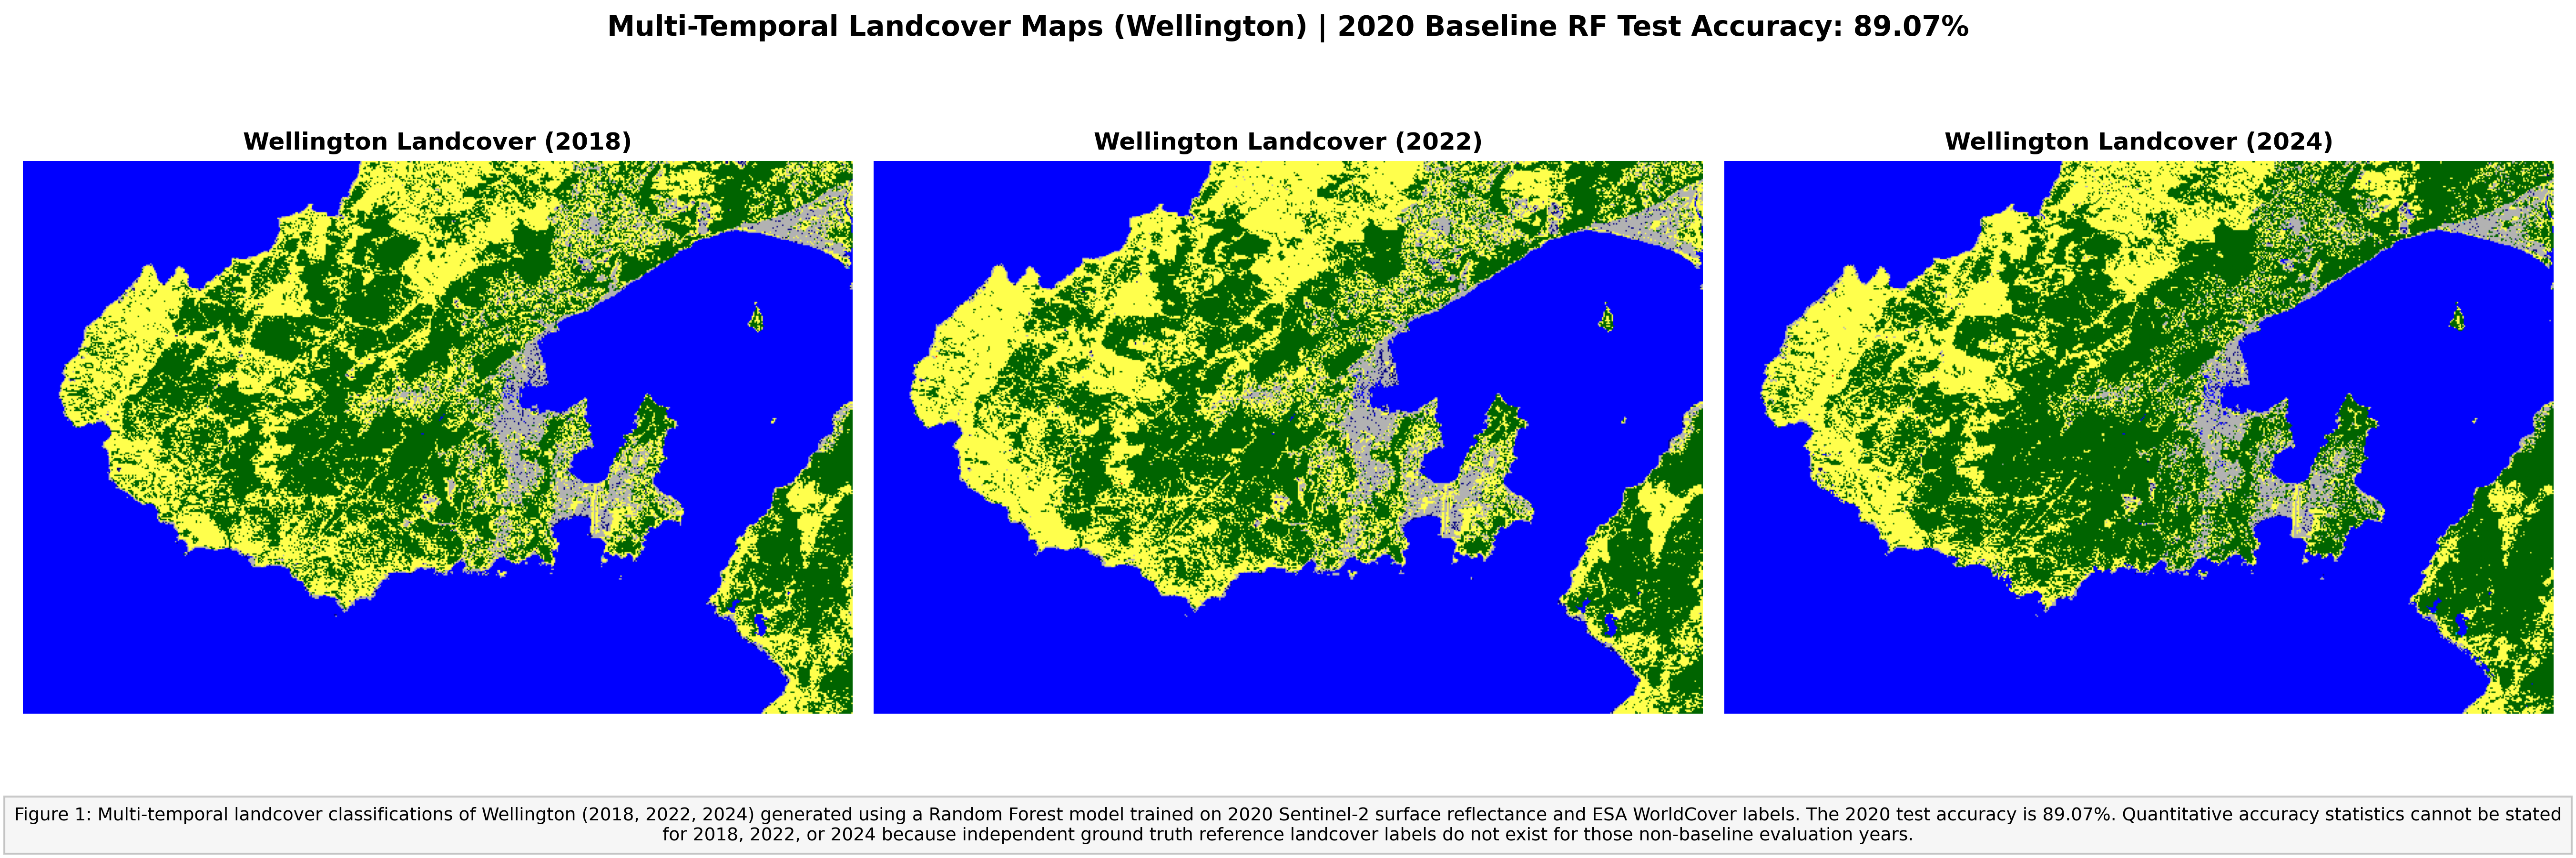

In [ ]:
import ee
import geemap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request
import tempfile
from sklearn.metrics import accuracy_score, classification_report

# ee.Initialize(project='earthengine-ml-testing')
ee.Initialize(project='earthenginetest-504004')


# 1. AOI and Bands setup
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
bands = ['B2', 'B3', 'B4', 'B8']

def get_s2_composite(year):
    def mask_s2(img):
        qa = img.select('QA60')
        mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        return img.updateMask(mask).divide(10000).select(bands)

    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(aoi)
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .map(mask_s2)
            .median()
            .clip(aoi))

# 2. Train RF on 2020 Data
s2_2020 = get_s2_composite(2020)
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)
valid_classes = ee.List.sequence(10, 100, 10)
remap_to = ee.List.sequence(1, 10)
lc_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

training_data = s2_2020.addBands(lc_remapped)
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi, scale=10, numPixels=5000, seed=2, geometries=True
).randomColumn('random')

train = sample.filter(ee.Filter.lt('random', 0.7))
test = sample.filter(ee.Filter.gte('random', 0.9))

rf_classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train, classProperty='Map_remapped', inputProperties=bands
)

# 3. Evaluate 2020 Baseline Performance
test_classified = test.classify(rf_classifier, 'predicted')
y_true = test_classified.aggregate_array('Map_remapped').getInfo()
y_pred = test_classified.aggregate_array('predicted').getInfo()
acc_2020 = accuracy_score(y_true, y_pred) * 100

# 4. Classify 2018, 2022, 2024
years = [2018, 2022, 2024]
classified_maps = {yr: get_s2_composite(yr).classify(rf_classifier) for yr in years}

# 5. Publication Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=300)
vis = {'min': 1, 'max': 10, 'palette': ['006400', 'ffbb22', 'ffff4c', 'f00000', 'b2b2b2', '000080', 'fff0f7', '0000ff', '02c5ee', '8a2be2']}

for idx, yr in enumerate(years):
    url = classified_maps[yr].getThumbURL({'dimensions': 600, 'region': aoi, 'format': 'png', **vis})
    with tempfile.NamedTemporaryFile(suffix='.png') as f:
        urllib.request.urlretrieve(url, f.name)
        img = mpimg.imread(f.name)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Wellington Landcover ({yr})", fontsize=12, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle(f"Multi-Temporal Landcover Maps (Wellington) | 2020 Baseline RF Test Accuracy: {acc_2020:.2f}%", fontsize=14, fontweight='bold')
plt.figtext(0.5, 0.02,
            f"Figure 1: Multi-temporal landcover classifications of Wellington (2018, 2022, 2024) generated using a Random Forest model trained on 2020 Sentinel-2 surface reflectance and ESA WorldCover labels. The 2020 test accuracy is {acc_2020:.2f}%. Quantitative accuracy statistics cannot be stated for 2018, 2022, or 2024 because independent ground truth reference landcover labels do not exist for those non-baseline evaluation years.",
            ha="center", fontsize=9, wrap=True, bbox={"facecolor":"lightgrey", "alpha":0.2, "pad":5})

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("Wellington_Multitemporal_RF.png", dpi=300)
plt.show()

# SVMs Applied to Satellite Data

In [ ]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)


Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       230        1       31        0        2        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        39        0      154        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        3        0       23        2        0   
Actual 60         0        0        1        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        6        0        0   
Actual 90         0        0        3        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [ ]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp") #<- Check file names
print(gdf.head())


Saving lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip to lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip
           Name_2018          Name_2012          Name_2008          Name_2001  \
0  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
1     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
2  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
3     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
4  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   

           Name_1996  Class_2018  Class_2012  Class_2008  Class_2001  \
0  Indigenous Forest          69          69          69          69   
1     Sand or Gravel          10          10          10          10   
2  Indigenous Forest          69          69          69          69   
3     Sand or Gravel          10          10          10          1

In [ ]:
# Inspect what year columns exist
print([c for c in gdf.columns if 'Class' in c or 'class' in c])
gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp")
# Reproject to WGS84 to match GEE's expected CRS
gdf = gdf.to_crs("EPSG:4326")
print(gdf.shape)


['Class_2018', 'Class_2012', 'Class_2008', 'Class_2001', 'Class_1996']
(531, 24)


In [ ]:
# Great Barrier Island (Aotea) approximate bounding box
gbi_aoi = ee.Geometry.Rectangle([175.30, -36.35, 175.55, -36.05])

gbi_s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(gbi_aoi)
          .filterDate('2018-12-01', '2019-02-28')  # austral summer 18/19
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
          .map(mask_s2_clouds)
          .median()
          .clip(gbi_aoi))

In [ ]:
print("gdf exists:", 'gdf' in dir())
print(gdf.shape)

result = geemap.geopandas_to_ee(gdf)
print("Conversion done")
print(type(result))

lcdb_fc = result
print("lcdb_fc assigned")
print(lcdb_fc.size().getInfo())

gdf exists: True
(531, 24)
Conversion done
<class 'ee.featurecollection.FeatureCollection'>
lcdb_fc assigned
531


In [ ]:
class_col = 'Class_2018'

lcdb_fc_clipped = lcdb_fc.filterBounds(gbi_aoi)

training_gbi = gbi_s2.select(bands).sampleRegions(
    collection=lcdb_fc_clipped,
    properties=[class_col],
    scale=30,
    geometries=False,
    tileScale=4
)

print("Total samples:", training_gbi.size().getInfo())

training_gbi = training_gbi.randomColumn('rand_sub')
training_gbi = training_gbi.sort('rand_sub').limit(8000)

training_gbi = training_gbi.randomColumn('random')
train_gbi = training_gbi.filter(ee.Filter.lt('random', 0.7))
valid_gbi = training_gbi.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test_gbi  = training_gbi.filter(ee.Filter.gte('random', 0.9))

print("Train:", train_gbi.size().getInfo(), "Valid:", valid_gbi.size().getInfo(), "Test:", test_gbi.size().getInfo())

Total samples: 399529
Train: 5714 Valid: 1532 Test: 754


In [ ]:
svm_gbi = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train_gbi,
    classProperty=class_col,
    inputProperties=bands
)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

tested_gbi = test_gbi.classify(svm_gbi, 'predicted')

def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

y_true_gbi, y_pred_gbi = fc_to_lists(tested_gbi, class_col, 'predicted')
gbi_labels = sorted(set(y_true_gbi) | set(y_pred_gbi))

cm_gbi = confusion_matrix(y_true_gbi, y_pred_gbi, labels=gbi_labels)
report_gbi = classification_report(y_true_gbi, y_pred_gbi, labels=gbi_labels, zero_division=0)
test_accuracy_gbi = accuracy_score(y_true_gbi, y_pred_gbi)

print(pd.DataFrame(cm_gbi, index=[f"Actual {l}" for l in gbi_labels], columns=[f"Pred {l}" for l in gbi_labels]))
print(report_gbi)
print(f"Overall Test Accuracy: {test_accuracy_gbi:.3f}")

           Pred 1  Pred 10  Pred 21  Pred 22  Pred 33  Pred 40  Pred 41  \
Actual 1        0        0        0        0        0        0        0   
Actual 10       0        0        0        0        0        0        0   
Actual 21       0        0        0        0        0        0        0   
Actual 22       0        0        0        0        0        0        0   
Actual 33       0        0        0        0        0        0        0   
Actual 40       0        0        0        0        0        0        0   
Actual 41       0        0        0        0        0        0        0   
Actual 45       0        0        0        0        0        0        0   
Actual 46       0        0        0        0        0        0        0   
Actual 51       0        0        0        0        0        0        0   
Actual 52       0        0        0        0        0        0        0   
Actual 54       0        0        0        0        0        0        0   
Actual 69       0        

In [ ]:
classified_gbi = gbi_s2.select(bands).classify(svm_gbi)

In [ ]:
import numpy as np

def ee_image_to_array(image, region, scale=30):
    arr = geemap.ee_to_numpy(image, region=region, scale=scale)
    return arr[:, :, 0]

gbi_array = ee_image_to_array(classified_gbi, gbi_aoi, scale=30)

In [ ]:
# Simple NDWI-based water mask to exclude ocean before plotting
ndwi = gbi_s2.normalizedDifference(['B3', 'B8']).rename('NDWI')
water_mask = ndwi.lt(0.1)  # non-water pixels only; tune threshold if ocean still leaks through

classified_gbi_masked = classified_gbi.updateMask(water_mask)

In [ ]:
gbi_array = ee_image_to_array(classified_gbi_masked, gbi_aoi, scale=60)
gbi_array = gbi_array.astype(float)
gbi_array[gbi_array == 0] = np.nan

print(gbi_array.shape)
print(np.unique(gbi_array[~np.isnan(gbi_array)]))

(558, 465)
[10. 40. 52. 69.]


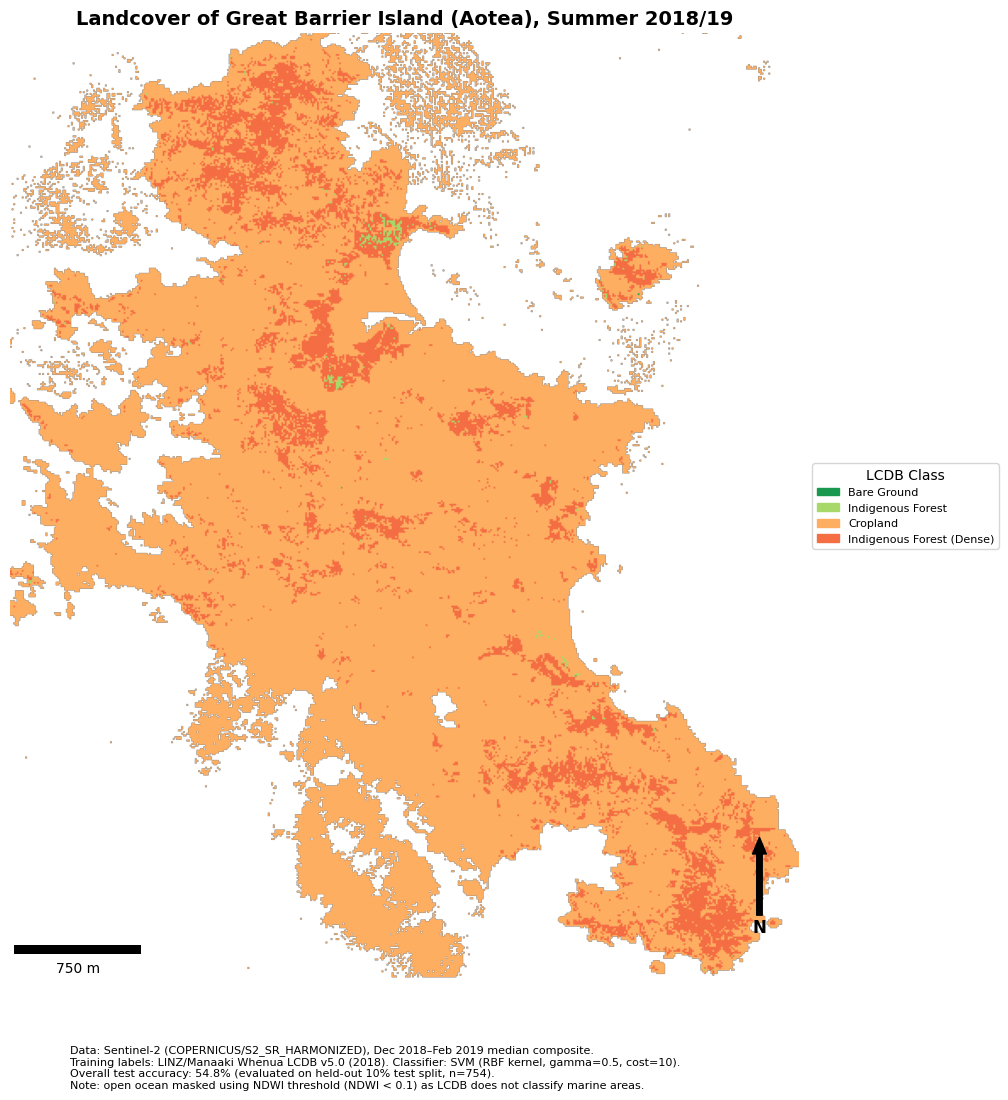

In [ ]:
# !pip install matplotlib-scalebar
from matplotlib_scalebar.scalebar import ScaleBar
import numpy.ma as ma

gbi_array_idx = np.full(gbi_array.shape, np.nan, dtype=float)
for idx, cls_val in enumerate(unique_classes):
    gbi_array_idx[gbi_array == cls_val] = idx

masked_array = ma.masked_invalid(gbi_array_idx)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('lightblue')
im = ax.imshow(masked_array, cmap=cmap, vmin=0, vmax=n_classes-1)
ax.set_title('Landcover of Great Barrier Island (Aotea), Summer 2018/19', fontsize=14, fontweight='bold')
ax.axis('off')

patches = [plt.Rectangle((0,0),1,1, color=cmap_colors[i]) for i in range(n_classes)]
labels = [class_lookup.get(c, str(c)) for c in unique_classes]
ax.legend(patches, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8, title='LCDB Class')

scale = 10
ax.add_artist(ScaleBar(scale, location='lower left'))

ax.annotate('N', xy=(0.95, 0.15), xytext=(0.95, 0.05), xycoords='axes fraction',
            arrowprops=dict(facecolor='black', width=4, headwidth=10),
            ha='center', fontsize=12, fontweight='bold')

caption = (
    f"Data: Sentinel-2 (COPERNICUS/S2_SR_HARMONIZED), Dec 2018–Feb 2019 median composite.\n"
    f"Training labels: LINZ/Manaaki Whenua LCDB v5.0 (2018). Classifier: SVM (RBF kernel, gamma=0.5, cost=10).\n"
    f"Overall test accuracy: {test_accuracy_gbi:.1%} (evaluated on held-out 10% test split, n=754).\n"
    f"Note: open ocean masked using NDWI threshold (NDWI < 0.1) as LCDB does not classify marine areas."
)
fig.text(0.1, -0.05, caption, ha='left', va='top', fontsize=8)

plt.tight_layout()
plt.savefig('great_barrier_island_landcover_2018_masked.png',
            dpi=300, bbox_inches='tight', facecolor='lightblue')
plt.show()